# AQI Forecasting — XGBoost Model
**Station:** Kodungaiyur  
**Dataset:** `Kodungaiyur_AQI_cleaned.csv` (43,819 hourly rows, Jan 2021–Dec 2025)  
**Target:** Hourly AQI  
**Model:** XGBoost with EDA-driven features

> **EDA-driven decisions (EDA Sec 10):**
> - Hourly granularity — more rows → better tree generalisation  
> - Lag 1–48 h (ACF shows r≥0.88 at lag-1; still significant past lag-24)  
> - Cyclic Hour_sin/cos, Month_sin/cos (diurnal peak 08-10 h, 20-22 h; Nov-Jan seasonal peak)  
> - All pollutants (PM25, PM10, CO, NOx r > 0.6 with AQI) + weather covariates (WS negative r)  
> - 70/15/15 chronological train/val/test — NO random shuffling  
> - No stationarity pre-processing needed (XGBoost is non-parametric)  


## 0. Environment Setup

In [1]:
try:
    import xgboost
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})

print(f'XGBoost version : {xgb.__version__}')
print('Libraries loaded successfully.')


XGBoost version : 2.1.3
Libraries loaded successfully.


## 1. Load & Inspect Data

In [3]:
# Update DATA_PATH if running locally
DATA_PATH    = f'D:\\AQI_Project_new\\data\\clean\\{STATION_NAME}_AQI_cleaned.csv'
STATION_NAME = 'Kodungaiyur'

df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'Shape       : {df.shape}')
print(f'Date range  : {df["Timestamp"].min()}  ->  {df["Timestamp"].max()}')
print(f'Total nulls : {df.isnull().sum().sum()}')
df.head(3)


Shape       : (43819, 20)
Date range  : 2021-01-01 05:00:00  ->  2025-12-31 23:00:00
Total nulls : 0


,Timestamp,NO,NOx,Benzene,Toluene,RH,WS,WD,RF,TOT-RF,SR,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
0,2021-01-01 05:00:00,1.58,5.68,0.24,0.41,70.46,2.4,238.14,0.0,0.0,154.51,84.46,92.36,10.38,7.9,4.7,22.96,19.26,22.96,Good
1,2021-01-01 06:00:00,1.58,5.68,0.24,0.41,70.46,2.4,238.14,0.0,0.0,154.51,84.46,92.36,10.38,7.9,4.7,23.62,19.92,23.62,Good
2,2021-01-01 07:00:00,1.58,5.68,0.24,0.41,70.46,2.4,238.14,0.0,0.0,154.51,84.46,92.36,10.38,7.9,4.7,23.34,18.83,23.34,Good


In [4]:
POLLUTANT_COLS = [c for c in ['NO','NOx','Benzene','Toluene','PM25','PM10','NO2','SO2','NH3','CO','O3'] if c in df.columns]
WEATHER_COLS   = [c for c in ['RH','WS','WD','RF','TOT-RF','SR'] if c in df.columns]

print(f'Pollutant features ({len(POLLUTANT_COLS)}): {POLLUTANT_COLS}')
print(f'Weather   features ({len(WEATHER_COLS)}): {WEATHER_COLS}')
df.describe().T


Pollutant features (11): ['NO', 'NOx', 'Benzene', 'Toluene', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3']
Weather   features (6): ['RH', 'WS', 'WD', 'RF', 'TOT-RF', 'SR']


,count,mean,min,25%,50%,75%,max,std
Timestamp,43819,2023-07-03 02:00:00,2021-01-01 05:00:00,2022-04-02 15:30:00,2023-07-03 02:00:00,2024-10-01 12:30:00,2025-12-31 23:00:00,NaN
NO,43819.0,3.318479,0.22,2.14,2.85,3.89,50.99,2.425715
NOx,43819.0,9.266636,0.0,7.02,8.85,11.08,45.43,3.457915
Benzene,43819.0,1.622468,0.0,1.12,1.24,1.66,19.45,1.283258
Toluene,43819.0,5.899206,0.0,2.75,4.72,6.94,56.74,5.455271
RH,43819.0,68.357862,1.47,67.45,68.95,70.08,74.55,4.425629
WS,43819.0,1.942692,0.27,1.46,1.88,2.34,5.51,0.658986
WD,43819.0,233.760154,33.03,187.64,236.77,278.25,357.79,63.82528
RF,43819.0,0.087449,0.0,0.0,0.0,0.0,4.47,0.308031
TOT-RF,43819.0,0.077211,0.0,0.0,0.0,0.0,4.15,0.279316


## 2. Feature Engineering

### EDA-justified feature groups
| Feature group | EDA justification |
|---|---|
| Lag 1-48 h | ACF r>=0.88 at lag-1; significant beyond lag-24 (Sec 9.2) |
| Roll mean/std 3, 6, 24 h | Smooth diurnal cycle; captures short-run volatility |
| Hour sin/cos | Dual-peak diurnal pattern 08-10 h, 20-22 h (Sec 4.1) |
| Month sin/cos | Strong annual cycle — Nov-Jan peak (Sec 4.2) |
| DoW sin/cos, IsWeekend | Day-of-week AQI variation (Sec 4.1) |
| DayOfYear sin/cos | Annual cyclic position |
| Season (encoded) | Categorical seasonality (Sec 4.2) |
| All pollutants | PM25, PM10, CO, NOx r > 0.6 with AQI (Sec 5.2) |
| Weather (WS, RH...) | WS has negative r (wind disperses pollutants) (Sec 5.2) |


In [5]:
def create_features(df_in):
    """Engineer all XGBoost features. Designed using EDA Sec 4, 5, 9, 10."""
    df_f = df_in.copy()

    # Lag features (1-48 h)
    for lag in [1, 2, 3, 6, 12, 18, 24, 36, 48]:
        df_f[f'lag_{lag}h'] = df_f['AQI'].shift(lag)

    # Rolling statistics (shift-1 to prevent leakage)
    for win in [3, 6, 24]:
        rolled = df_f['AQI'].shift(1).rolling(win)
        df_f[f'roll_mean_{win}h'] = rolled.mean()
        df_f[f'roll_std_{win}h']  = rolled.std()

    # Calendar features
    df_f['hour']        = df_f['Timestamp'].dt.hour
    df_f['day_of_week'] = df_f['Timestamp'].dt.dayofweek
    df_f['month']       = df_f['Timestamp'].dt.month
    df_f['day_of_year'] = df_f['Timestamp'].dt.dayofyear
    df_f['quarter']     = df_f['Timestamp'].dt.quarter
    df_f['is_weekend']  = (df_f['Timestamp'].dt.dayofweek >= 5).astype(int)

    # Cyclic encoding (EDA Sec 4.1 diurnal + Sec 4.2 annual)
    df_f['hour_sin']  = np.sin(2 * np.pi * df_f['hour']        / 24)
    df_f['hour_cos']  = np.cos(2 * np.pi * df_f['hour']        / 24)
    df_f['month_sin'] = np.sin(2 * np.pi * df_f['month']       / 12)
    df_f['month_cos'] = np.cos(2 * np.pi * df_f['month']       / 12)
    df_f['dow_sin']   = np.sin(2 * np.pi * df_f['day_of_week'] / 7)
    df_f['dow_cos']   = np.cos(2 * np.pi * df_f['day_of_week'] / 7)
    df_f['doy_sin']   = np.sin(2 * np.pi * df_f['day_of_year'] / 365)
    df_f['doy_cos']   = np.cos(2 * np.pi * df_f['day_of_year'] / 365)

    # Season encoding (EDA Sec 4.2)
    season_map = {12:0, 1:0, 2:0, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:3, 10:3, 11:3}
    df_f['season'] = df_f['month'].map(season_map)

    return df_f


featured = create_features(df)
featured = featured.dropna()  # drop rows with NaN from lag creation

DROP_COLS    = ['Timestamp', 'AQI', 'AQI_Category']
FEATURE_COLS = [c for c in featured.columns if c not in DROP_COLS]

print(f'Feature count       : {len(FEATURE_COLS)}')
print(f'Rows after NaN drop : {len(featured):,}')
print('\nAll features:')
for f in FEATURE_COLS:
    print(f'  * {f}')


Feature count       : 47
Rows after NaN drop : 43,771

All features:
  * NO
  * NOx
  * Benzene
  * Toluene
  * RH
  * WS
  * WD
  * RF
  * TOT-RF
  * SR
  * PM25
  * PM10
  * NO2
  * SO2
  * NH3
  * CO
  * O3
  * lag_1h
  * lag_2h
  * lag_3h
  * lag_6h
  * lag_12h
  * lag_18h
  * lag_24h
  * lag_36h
  * lag_48h
  * roll_mean_3h
  * roll_std_3h
  * roll_mean_6h
  * roll_std_6h
  * roll_mean_24h
  * roll_std_24h
  * hour
  * day_of_week
  * month
  * day_of_year
  * quarter
  * is_weekend
  * hour_sin
  * hour_cos
  * month_sin
  * month_cos
  * dow_sin
  * dow_cos
  * doy_sin
  * doy_cos
  * season


## 3. Train / Validation / Test Split (Temporal 70 / 15 / 15)

> **EDA Sec 10.7:** "Always use TIME-BASED (chronological) splits. Random splits cause data leakage for all three models."


In [6]:
featured['AQI_next'] = featured['AQI'].shift(-1)
featured = featured.dropna(subset=['AQI_next'])

n         = len(featured)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = featured.iloc[:train_end]
val   = featured.iloc[train_end:val_end]
test  = featured.iloc[val_end:]

X_train, y_train = train[FEATURE_COLS], train['AQI_next']
X_val,   y_val   = val[FEATURE_COLS],   val['AQI_next']
X_test,  y_test  = test[FEATURE_COLS],  test['AQI_next']

print(f'Train : {len(train):>6,} rows  {train["Timestamp"].iloc[0].date()} -> {train["Timestamp"].iloc[-1].date()}')
print(f'Val   : {len(val):>6,} rows  {val["Timestamp"].iloc[0].date()} -> {val["Timestamp"].iloc[-1].date()}')
print(f'Test  : {len(test):>6,} rows  {test["Timestamp"].iloc[0].date()} -> {test["Timestamp"].iloc[-1].date()}')


Train : 30,638 rows  2021-01-03 -> 2024-07-02
Val   :  6,566 rows  2024-07-02 -> 2025-04-02
Test  :  6,566 rows  2025-04-02 -> 2025-12-31


## 4. Train XGBoost Model

In [7]:
model = xgb.XGBRegressor(
    n_estimators          = 1000,
    max_depth             = 6,
    learning_rate         = 0.02,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    min_child_weight      = 5,
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 40,
    eval_metric           = 'rmse',
    tree_method           = 'hist',   # fast on large hourly dataset
)

model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = 100,
)

print(f'Best iteration : {model.best_iteration}')
print(f'Best val RMSE  : {model.best_score:.4f}')


[0]	validation_0-rmse:30.72246
[100]	validation_0-rmse:6.86758
[200]	validation_0-rmse:5.41696
[300]	validation_0-rmse:5.29990
[400]	validation_0-rmse:5.23652
[500]	validation_0-rmse:5.20470
[555]	validation_0-rmse:5.20253
Best iteration : 515
Best val RMSE  : 5.2011


## 5. Forecast & Evaluation

### 5a. Direct Forecast (uses actual test-period pollutant & lag values)


In [8]:
pred_direct = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_direct))
mae  = mean_absolute_error(y_test, pred_direct)
mask = y_test.values != 0
mape = np.mean(np.abs((y_test.values[mask] - pred_direct[mask]) / y_test.values[mask])) * 100

print('XGBoost Direct Forecast (Hourly):')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')


XGBoost Direct Forecast (Hourly):
  RMSE : 18.1663
  MAE  : 5.5027
  MAPE : 4.96%


### 5b. Recursive Multi-Step Forecast (predicted AQI propagated into lag columns)


In [9]:
def recursive_forecast(model, train_df, test_df, feature_cols, lag_col_list):
    """Multi-step recursive forecast; predicted AQI fills lag columns."""
    all_data    = pd.concat([train_df, test_df]).copy()
    predictions = []
    n_train     = len(train_df)

    for i in range(n_train, len(all_data)):
        row  = all_data.iloc[i]
        feat = row[feature_cols].values.reshape(1, -1)
        pred = model.predict(feat)[0]
        predictions.append(pred)

        if i + 1 < len(all_data):
            for lag_col in lag_col_list:
                lag_h = int(lag_col.replace('lag_', '').replace('h', ''))
                if len(predictions) >= lag_h:
                    all_data.at[all_data.index[i + 1], lag_col] = predictions[-lag_h]

    return np.array(predictions)


lag_cols_h     = [c for c in FEATURE_COLS if c.startswith('lag_')]
pred_recursive = recursive_forecast(model, train, test, FEATURE_COLS, lag_cols_h)

rmse_r = np.sqrt(mean_squared_error(y_test, pred_recursive))
mae_r  = mean_absolute_error(y_test, pred_recursive)
mask_r = y_test.values != 0
mape_r = np.mean(np.abs((y_test.values[mask_r] - pred_recursive[mask_r]) / y_test.values[mask_r])) * 100

print('XGBoost Recursive Forecast (Hourly):')
print(f'  RMSE : {rmse_r:.4f}')
print(f'  MAE  : {mae_r:.4f}')
print(f'  MAPE : {mape_r:.2f}%')


XGBoost Recursive Forecast (Hourly):
  RMSE : 21.4949
  MAE  : 6.8090
  MAPE : 6.35%


## 6. Forecast Visualisation


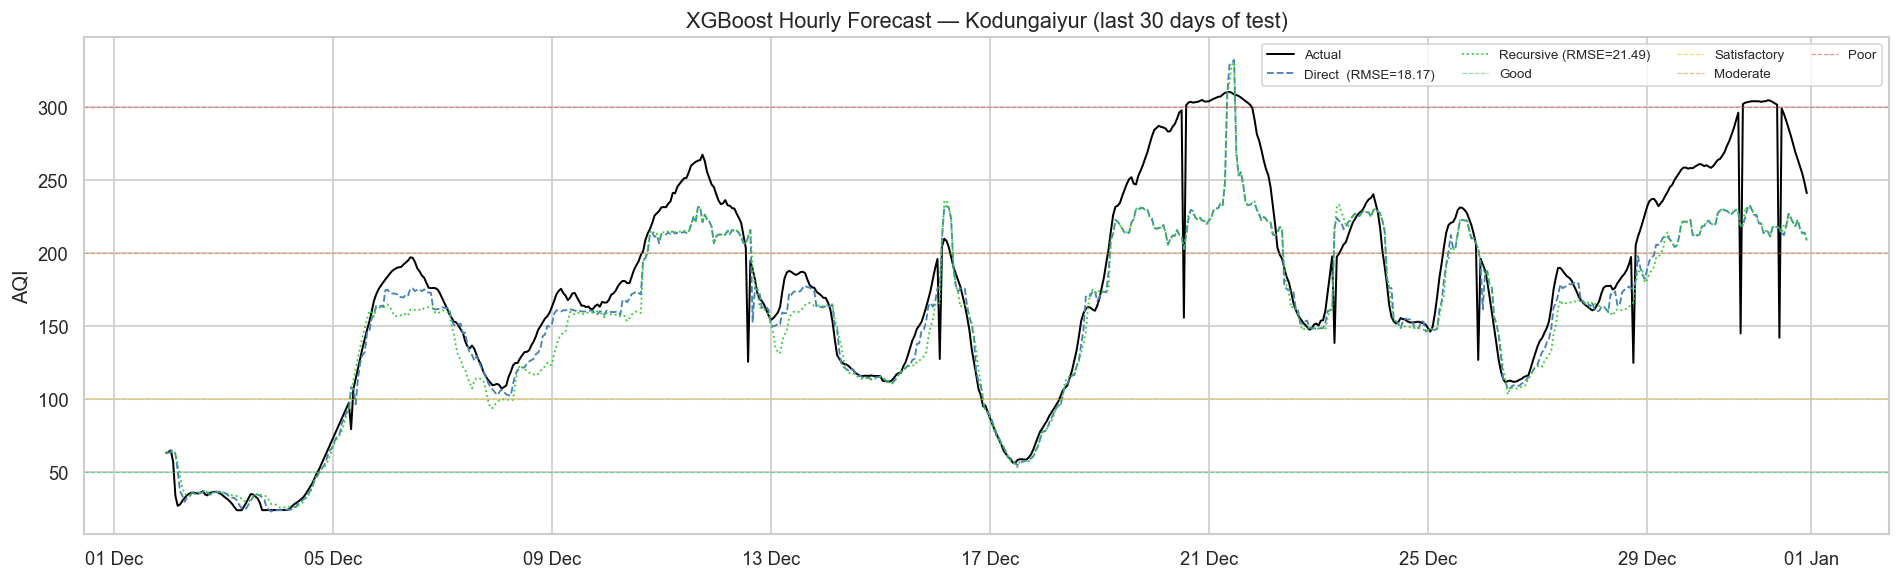

In [10]:
os.makedirs('images', exist_ok=True)

# Show last 30 days of test period for readability
plot_n   = min(30 * 24, len(y_test))
idx_plot = test['Timestamp'].iloc[-plot_n:]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(idx_plot, y_test.values[-plot_n:],
        label='Actual', color='black', lw=1.2)
ax.plot(idx_plot, pred_direct[-plot_n:],
        label=f'Direct  (RMSE={rmse:.2f})', color='steelblue', ls='--', lw=1.1)
ax.plot(idx_plot, pred_recursive[-plot_n:],
        label=f'Recursive (RMSE={rmse_r:.2f})', color='limegreen', ls=':', lw=1.1)

for val, col, lbl in [(50,'#2ecc71','Good'),(100,'#f1c40f','Satisfactory'),
                       (200,'#e67e22','Moderate'),(300,'#e74c3c','Poor')]:
    ax.axhline(val, color=col, lw=0.7, ls='--', alpha=0.6, label=lbl)

ax.set_title(f'XGBoost Hourly Forecast — {STATION_NAME} (last 30 days of test)', fontsize=13)
ax.set_ylabel('AQI')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.savefig(f'images/xgboost_forecast_{STATION_NAME}.png', dpi=150)
plt.show()


## 7. Feature Importance


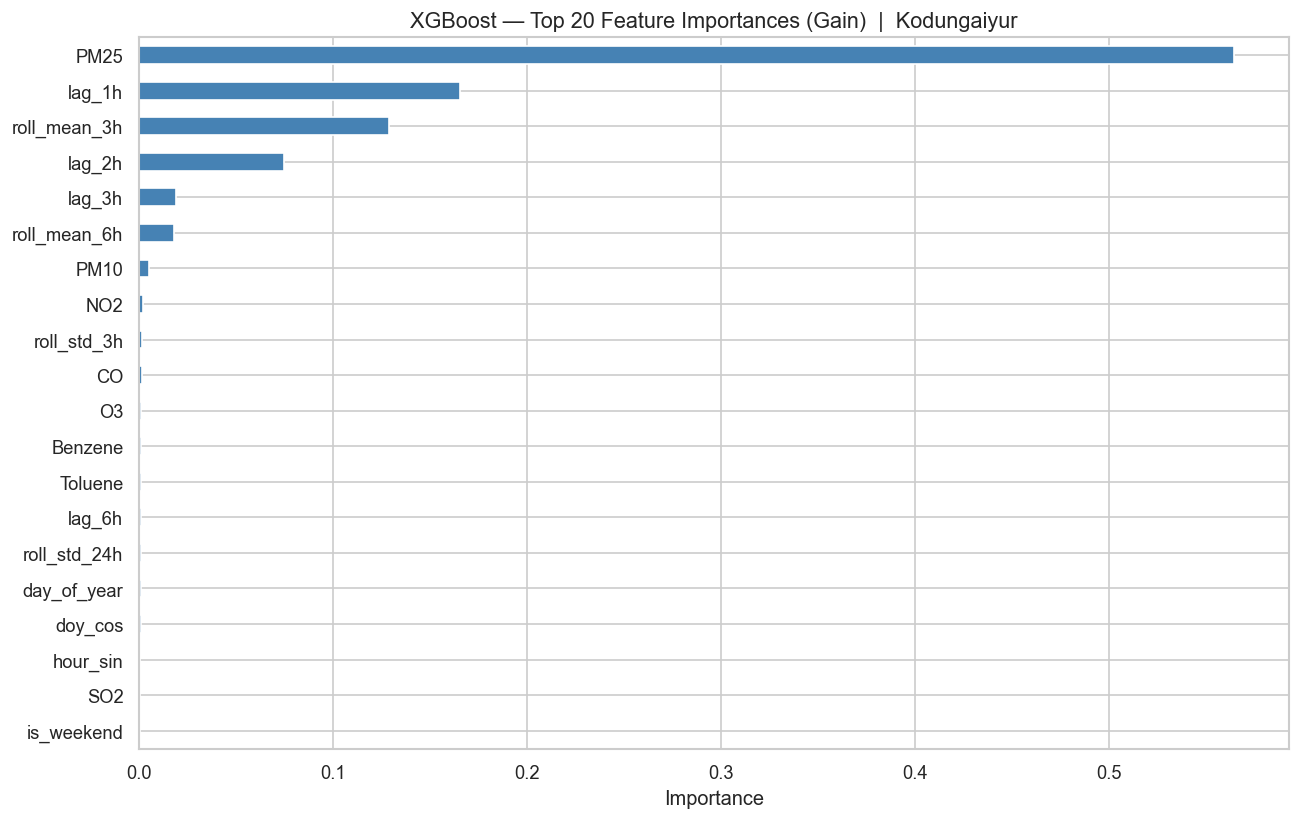

Top 20 features:
PM25            0.564553
lag_1h          0.165506
roll_mean_3h    0.128746
lag_2h          0.074802
lag_3h          0.019216
roll_mean_6h    0.017819
PM10            0.005111
NO2             0.001799
roll_std_3h     0.001443
CO              0.001348
O3              0.000923
Benzene         0.000796
Toluene         0.000740
lag_6h          0.000730
roll_std_24h    0.000717
day_of_year     0.000709
doy_cos         0.000676
hour_sin        0.000655
SO2             0.000645
is_weekend      0.000637


In [11]:
importance = pd.Series(
    model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
importance.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'XGBoost — Top 20 Feature Importances (Gain)  |  {STATION_NAME}', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'images/xgboost_feature_importance_{STATION_NAME}.png', dpi=150)
plt.show()

print('Top 20 features:')
print(importance.head(20).to_string())


## 8. Learning Curve


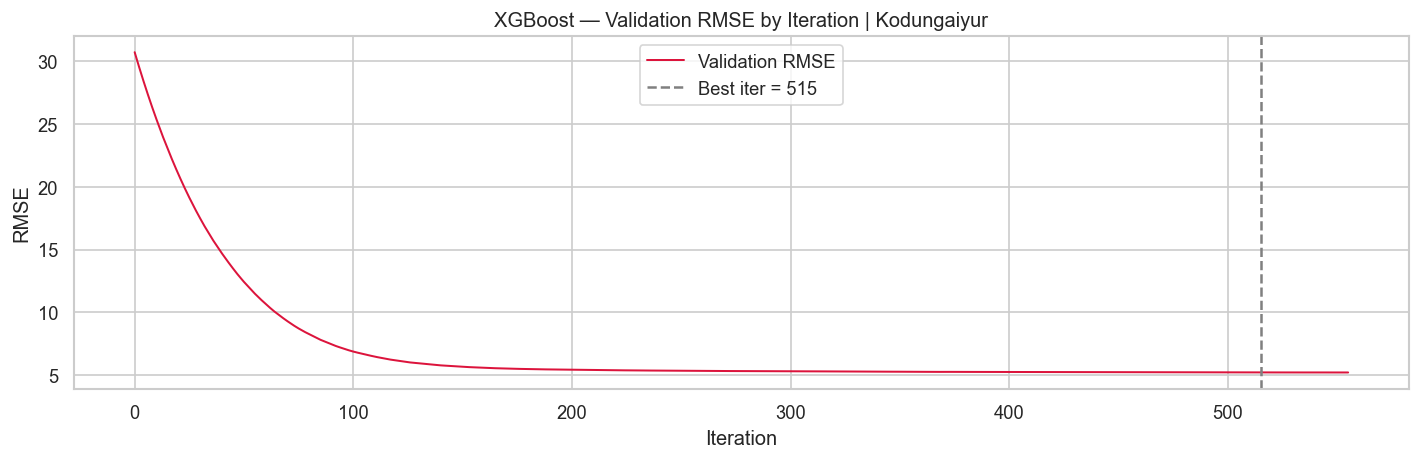

In [12]:
evals_result = model.evals_result()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(evals_result['validation_0']['rmse'], label='Validation RMSE', color='crimson', lw=1.2)
ax.axvline(model.best_iteration, ls='--', color='gray',
           label=f'Best iter = {model.best_iteration}')
ax.set_title(f'XGBoost — Validation RMSE by Iteration | {STATION_NAME}')
ax.set_xlabel('Iteration'); ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(f'images/xgboost_learning_curve_{STATION_NAME}.png', dpi=150)
plt.show()


## 9. AQI Category Classification Metrics

Continuous AQI predictions are mapped to Indian CPCB 6-class categories  
to evaluate Accuracy, Precision, Recall, and the Confusion Matrix.


Classification Metrics — AQI Categories (Recursive Forecast):
  Accuracy  : 0.9409
  Precision : 0.9373  (weighted)
  Recall    : 0.9409  (weighted)

              precision    recall  f1-score   support

        Good       0.95      0.97      0.96      1987
Satisfactory       0.96      0.97      0.96      3375
    Moderate       0.89      0.90      0.90       882
        Poor       0.74      0.83      0.78       205
   Very Poor       1.00      0.31      0.48        83
      Severe       0.00      0.00      0.00        34

    accuracy                           0.94      6566
   macro avg       0.76      0.66      0.68      6566
weighted avg       0.94      0.94      0.94      6566



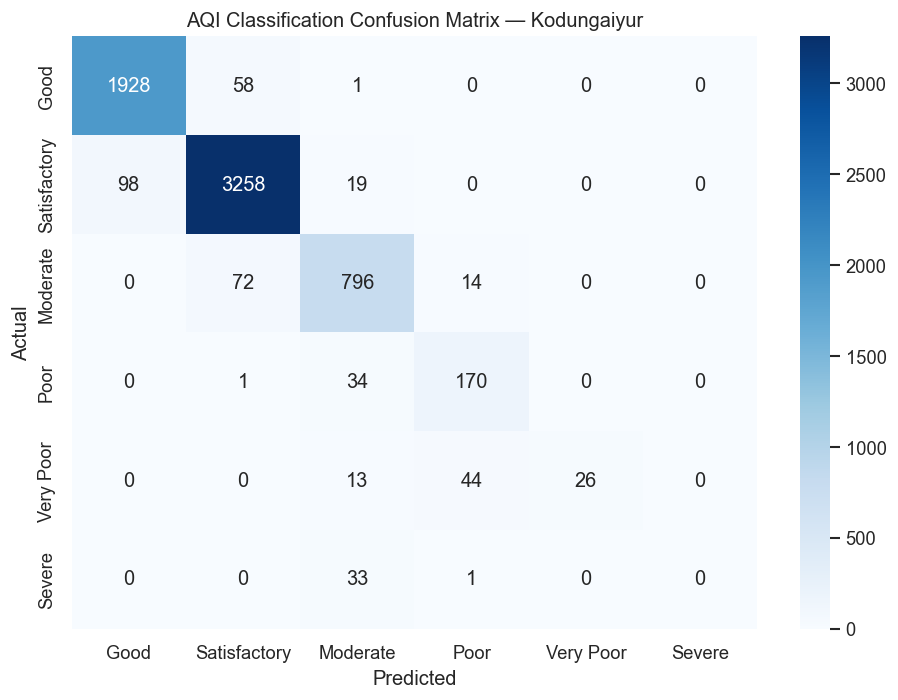

In [13]:
def categorize_aqi(aqi_values):
    """Map continuous AQI to Indian CPCB 6-class categories."""
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)


y_true_class   = categorize_aqi(y_test.values.flatten())
y_pred_class   = categorize_aqi(pred_recursive.flatten())

LABELS         = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
present_labels = [l for l in LABELS if l in y_true_class or l in y_pred_class]

acc  = accuracy_score(y_true_class, y_pred_class)
prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
rec  = recall_score(y_true_class,   y_pred_class, average='weighted', zero_division=0)

print('Classification Metrics — AQI Categories (Recursive Forecast):')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}  (weighted)')
print(f'  Recall    : {rec:.4f}  (weighted)')
print()
print(classification_report(y_true_class, y_pred_class, labels=present_labels, zero_division=0))

cm = confusion_matrix(y_true_class, y_pred_class, labels=present_labels)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels, yticklabels=present_labels, ax=ax)
ax.set_title(f'AQI Classification Confusion Matrix — {STATION_NAME}')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'images/xgboost_confusion_matrix_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Residual Analysis

Checking forecast errors by hour of day (aligned with EDA Sec 4.1 diurnal finding)
and an actual vs predicted scatter plot.


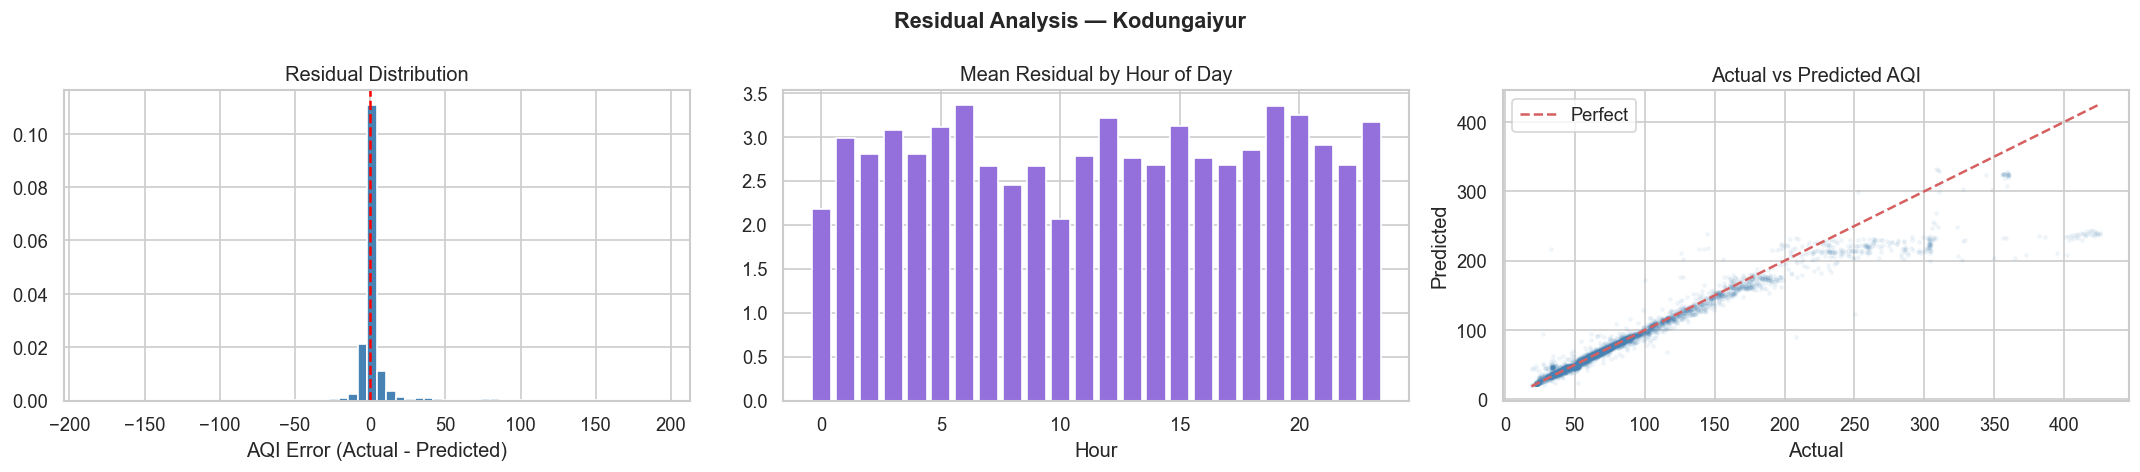

In [14]:
residuals = y_test.values - pred_direct

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Residual distribution
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', density=True)
axes[0].axvline(0, color='red', lw=1.5, ls='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('AQI Error (Actual - Predicted)')

# Residuals by hour of day
test_copy = test.copy()
test_copy['residual'] = residuals
hourly_resid = test_copy.groupby('hour')['residual'].mean()
axes[1].bar(hourly_resid.index, hourly_resid.values, color='mediumpurple', edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Mean Residual by Hour of Day')
axes[1].set_xlabel('Hour')

# Actual vs Predicted
axes[2].scatter(y_test.values, pred_direct, alpha=0.05, s=4, color='steelblue')
lims = [min(y_test.min(), pred_direct.min()), max(y_test.max(), pred_direct.max())]
axes[2].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[2].set_title('Actual vs Predicted AQI')
axes[2].set_xlabel('Actual'); axes[2].set_ylabel('Predicted')
axes[2].legend()

plt.suptitle(f'Residual Analysis — {STATION_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'images/xgboost_residuals_{STATION_NAME}.png', dpi=150)
plt.show()


## 11. Save Model & Feature List


In [15]:
import joblib

os.makedirs('saved_models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
MODEL_PATH   = f'saved_models/{STATION_NAME}_xgboost_aqi.pkl'
FEATURE_PATH = f'outputs/{STATION_NAME}_xgboost_features.json'

joblib.dump(model, MODEL_PATH)
import json
with open(FEATURE_PATH, 'w') as fp:
    json.dump(FEATURE_COLS, fp, indent=2)

print(f'Model saved   : {MODEL_PATH}')
print(f'Features saved: {FEATURE_PATH}')
print(f'Best iteration: {model.best_iteration}')
print(f'Direct RMSE   : {rmse:.4f}')
print(f'Recursive RMSE: {rmse_r:.4f}')


Model saved   : saved_models/Kodungaiyur_xgboost_aqi.pkl
Features saved: saved_models/Kodungaiyur_xgboost_features.txt
Best iteration: 515
Direct RMSE   : 18.1663
Recursive RMSE: 21.4949


## 12. Results Summary


In [16]:
print('=' * 65)
print(f'  XGBOOST AQI FORECAST — {STATION_NAME.upper()}')
print('=' * 65)
print(f'  Granularity      : Hourly (recommended by EDA Sec 10)')
print(f'  Features         : {len(FEATURE_COLS)} total')
print(f'  Train rows       : {len(X_train):,}')
print(f'  Val   rows       : {len(X_val):,}')
print(f'  Test  rows       : {len(X_test):,}')
print(f'  Best iteration   : {model.best_iteration}')
print()
print('  Direct Forecast  :')
print(f'    RMSE = {rmse:.4f}')
print(f'    MAE  = {mae:.4f}')
print(f'    MAPE = {mape:.2f}%')
print()
print('  Recursive Forecast:')
print(f'    RMSE = {rmse_r:.4f}')
print(f'    MAE  = {mae_r:.4f}')
print(f'    MAPE = {mape_r:.2f}%')
print()
print('  Classification (recursive, weighted):')
print(f'    Accuracy  = {acc:.4f}')
print(f'    Precision = {prec:.4f}')
print(f'    Recall    = {rec:.4f}')
print('=' * 65)


  XGBOOST AQI FORECAST — KODUNGAIYUR
  Granularity      : Hourly (recommended by EDA Sec 10)
  Features         : 47 total
  Train rows       : 30,638
  Val   rows       : 6,566
  Test  rows       : 6,566
  Best iteration   : 515

  Direct Forecast  :
    RMSE = 18.1663
    MAE  = 5.5027
    MAPE = 4.96%

  Recursive Forecast:
    RMSE = 21.4949
    MAE  = 6.8090
    MAPE = 6.35%

  Classification (recursive, weighted):
    Accuracy  = 0.9409
    Precision = 0.9373
    Recall    = 0.9409
